In [1]:
!pip install wordcloud seaborn

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from wordcloud import WordCloud

import warnings
warnings.filterwarnings("ignore")

plt.style.use("ggplot")

In [7]:
from google.colab import files



In [8]:
!unzip -o zomato.csv.zip
df = pd.read_csv("zomato.csv", encoding='latin1')

df.head()

Archive:  zomato.csv.zip
  inflating: zomato.csv              


,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
0,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,Buffet
1,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,Buffet
2,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,Buffet
3,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,Buffet
4,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,Buffet


In [9]:
print(df.shape)

df.info()

df.describe(include='all')

(56252, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56252 entries, 0 to 56251
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   address                      56235 non-null  object
 1   name                         56236 non-null  object
 2   online_order                 56233 non-null  object
 3   book_table                   56194 non-null  object
 4   rate                         48414 non-null  object
 5   votes                        56174 non-null  object
 6   phone                        54956 non-null  object
 7   location                     56126 non-null  object
 8   rest_type                    55914 non-null  object
 9   dish_liked                   28027 non-null  object
 10  cuisines                     56049 non-null  object
 11  approx_cost(for two people)  55731 non-null  object
 12  listed_in(type)              51642 non-null  object
dtypes: object(13)
memor

,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),listed_in(type)
count,56235,56236,56233,56194,48414,56174,54956,56126,55914,28027,56049,55731,51642
unique,13397,11914,2639,2902,2877,5195,17712,2920,2961,8067,5553,2879,2783
top,('Rated 4.0',('Rated 4.0',Yes,No,NEW,0,('Rated 4.0',BTM,Quick Bites,('Rated 4.0',North Indian,300,Delivery
freq,942,300,30444,45268,2208,10027,412,5125,19132,407,2913,7576,24317


In [10]:
df.isnull().sum()


,0
address,17
name,16
online_order,19
book_table,58
rate,7838
votes,78
phone,1296
location,126
rest_type,338
dish_liked,28225


In [43]:


text_cols = df.select_dtypes(include='object').columns

for col in text_cols:
    df[col] = df[col].fillna("Unknown")



num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [13]:
if 'Cuisines' in df.columns:
    df['Cuisines'] = df['Cuisines'].str.lower()
    df['Cuisines'] = df['Cuisines'].str.strip()

In [14]:
if 'Currency' in df.columns and 'Average Cost for two' in df.columns:

    conversion = {
        'Indian Rupees(Rs.)':1,
        'Dollar($)':83,
        'Pounds(£)':105,
        'Emirati Diram(AED)':22,
        'Brazilian Real(R$)':17,
        'NewZealand($)':50,
        'Rand(R)':4.5
    }

    df['Cost_INR'] = df.apply(
        lambda x: x['Average Cost for two']*conversion.get(x['Currency'],1),
        axis=1
    )

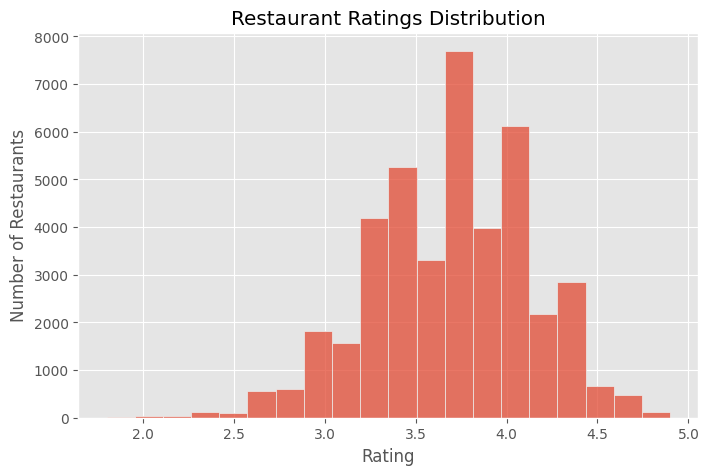

In [19]:


def clean_rate(rate_str):
    if isinstance(rate_str, str):
        if 'NEW' in rate_str or 'Unknown' in rate_str:
            return np.nan
        else:
            try:
                return float(rate_str.split('/')[0])
            except ValueError:
                return np.nan
    return rate_str

df['rate_cleaned'] = df['rate'].apply(clean_rate)


plt.figure(figsize=(8,5))
sns.histplot(df['rate_cleaned'].dropna(), bins=20)
plt.title("Restaurant Ratings Distribution")
plt.xlabel("Rating")
plt.ylabel("Number of Restaurants")
plt.show()

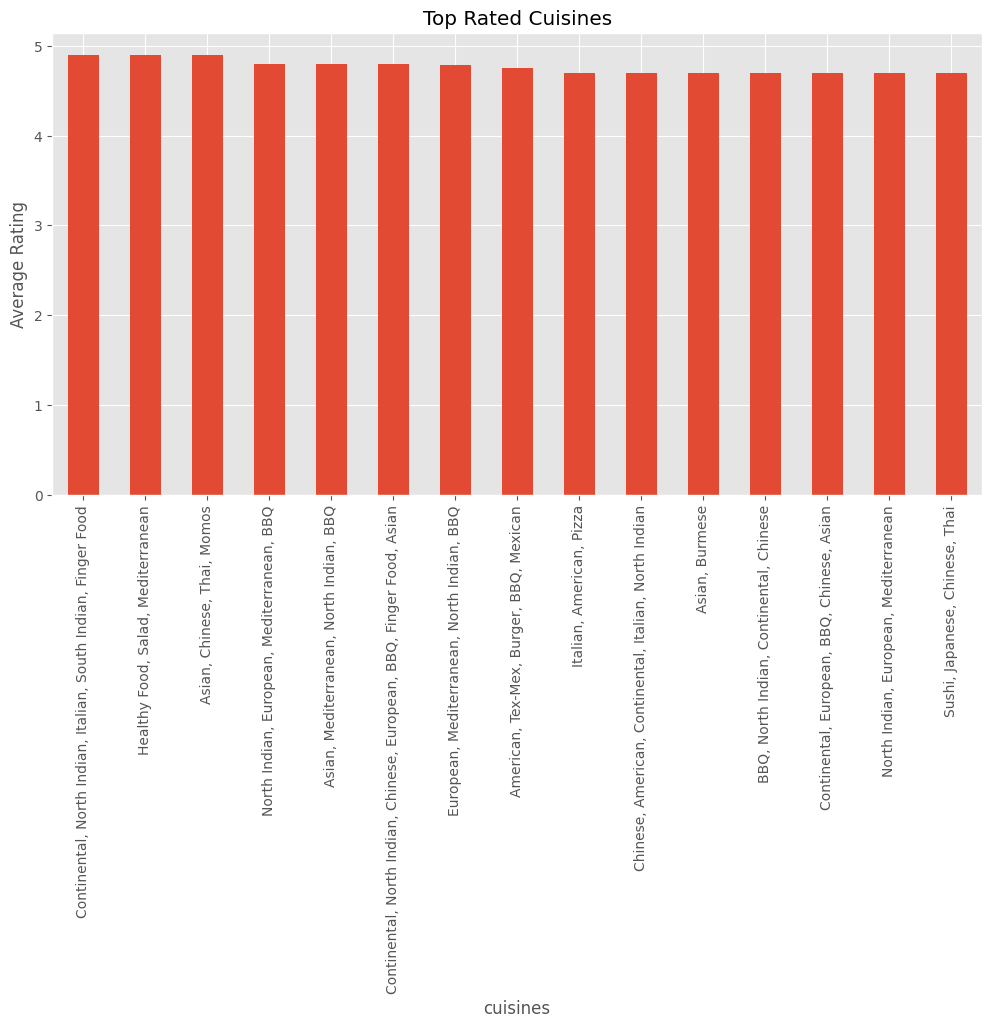

In [21]:
top_cuisine = (df.groupby("cuisines")["rate_cleaned"]
.mean()
.sort_values(ascending=False)
.head(15))

plt.figure(figsize=(12,6))

top_cuisine.plot(kind='bar')

plt.title("Top Rated Cuisines")

plt.ylabel("Average Rating")

plt.show()

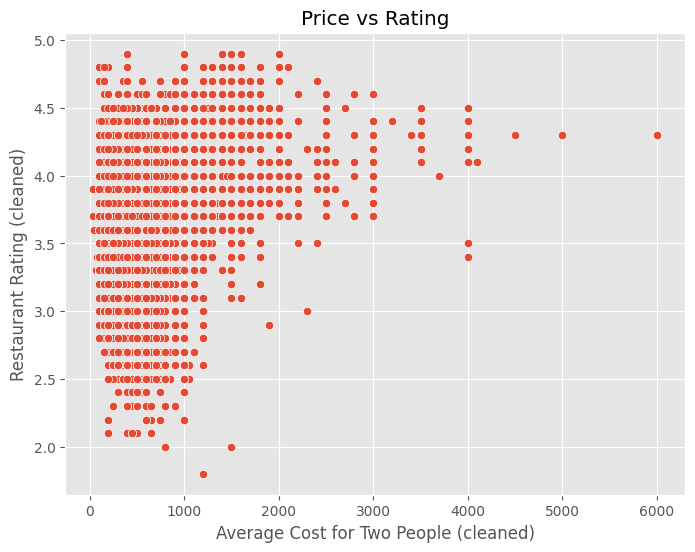

In [23]:

def clean_cost(cost_str):
    if isinstance(cost_str, str):
        cost_str = cost_str.replace(',', '')
        try:
            return float(cost_str)
        except ValueError:
            return np.nan
    return cost_str

df['cost_cleaned'] = df['approx_cost(for two people)'].apply(clean_cost)

plt.figure(figsize=(8,6))

sns.scatterplot(
    x='cost_cleaned',
    y='rate_cleaned',
    data=df
)

plt.title("Price vs Rating")
plt.xlabel("Average Cost for Two People (cleaned)")
plt.ylabel("Restaurant Rating (cleaned)")
plt.show()

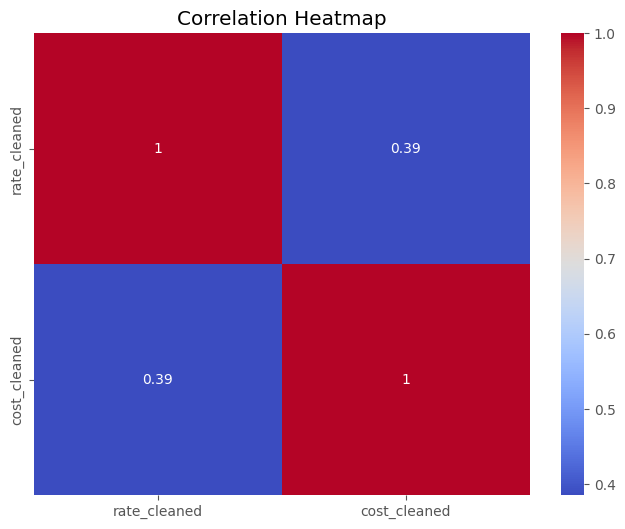

In [24]:
plt.figure(figsize=(8,6))

numeric = df.select_dtypes(include=np.number)

sns.heatmap(
    numeric.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [25]:
if 'City' in df.columns:

    city = df['City'].value_counts().head(15)

    plt.figure(figsize=(10,6))

    sns.barplot(
        x=city.values,
        y=city.index
    )

    plt.title("Restaurant Hotspots")

    plt.xlabel("Number of Restaurants")

    plt.show()

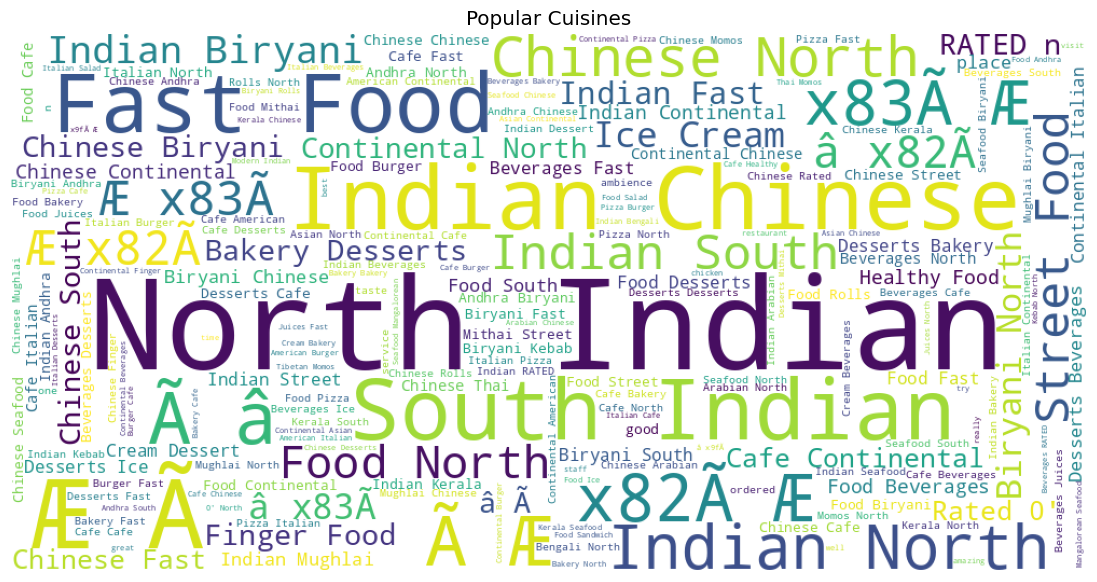

In [27]:
text = " ".join(df["cuisines"])

wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color='white'
).generate(text)

plt.figure(figsize=(14,7))

plt.imshow(wordcloud)

plt.axis("off")

plt.title("Popular Cuisines")

plt.show()

In [28]:
review_col = None

for col in df.columns:
    if "review" in col.lower():
        review_col = col
        break

if review_col:

    text = " ".join(df[review_col].astype(str))

    wc = WordCloud(
        width=1200,
        height=600,
        background_color='white'
    ).generate(text)

    plt.figure(figsize=(15,7))

    plt.imshow(wc)

    plt.axis("off")

    plt.show()

else:
    print("Review text column not available.")

Review text column not available.


In [29]:
if 'Has Online delivery' in df.columns:

    sns.countplot(
        x='Has Online delivery',
        data=df
    )

    plt.title("Online Delivery")

    plt.show()

In [30]:
if 'Has Table booking' in df.columns:

    sns.countplot(
        x='Has Table booking',
        data=df
    )

    plt.title("Table Booking")

    plt.show()

In [32]:
top = df.sort_values(
    by="rate_cleaned",
    ascending=False
)

top[['name',
     'location',
     'rate_cleaned',
     'votes']].head(10)

,name,location,rate_cleaned,votes
10897,Belgian Waffle Factory,Koramangala 5th Block,4.9,201
8366,Flechazo,Whitefield,4.9,2745
45826,Belgian Waffle Factory,Brigade Road,4.9,1750
30330,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9,2227
36443,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9,2249
4076,Byg Brewski Brewing Company,Sarjapur Road,4.9,16345
19062,Belgian Waffle Factory,Brigade Road,4.9,1735
23209,AB's - Absolute Barbecues,BTM,4.9,6404
5405,Belgian Waffle Factory,Brigade Road,4.9,1746
9647,Asia Kitchen By Mainland China,Koramangala 5th Block,4.9,2178


In [35]:
popular = df.groupby('location').agg({
    'name':'count',
    'rate_cleaned':'mean'
})

popular.rename(columns={
    'name':'Restaurants'
}, inplace=True)

popular.sort_values(
    by='Restaurants',
    ascending=False
).head(10)

,Restaurants,rate_cleaned
location,,
BTM,5125,3.573740
HSR,2523,3.672164
Koramangala 5th Block,2504,4.005821
JP Nagar,2235,3.675306
Whitefield,2144,3.621618
Indiranagar,2083,3.828154
Jayanagar,1926,3.780280
Marathahalli,1846,3.541927
Bannerghatta Road,1630,3.507449


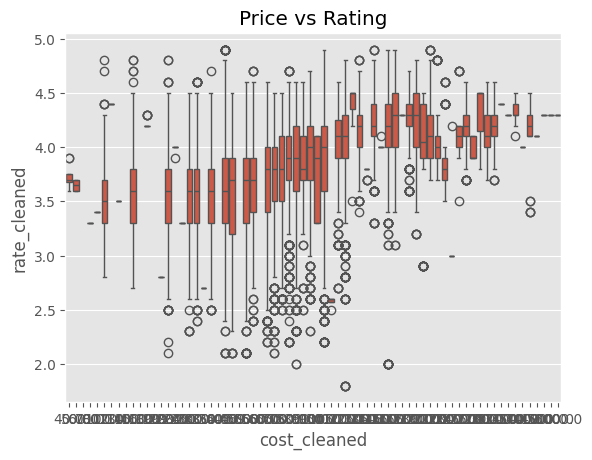

In [37]:
sns.boxplot(
    x='cost_cleaned',
    y='rate_cleaned',
    data=df
)

plt.title("Price vs Rating")

plt.show()

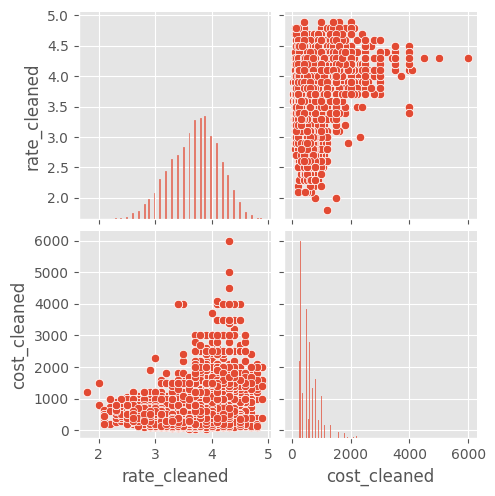

In [39]:
cols = [
    'rate_cleaned',
    'votes',
    'cost_cleaned'
]

sns.pairplot(df[cols])

plt.show()

In [41]:
print("Top Cuisine:")

print(df.groupby("cuisines")["rate_cleaned"].mean().sort_values(ascending=False).head())

print()

print("Top Cities")

print(df["location"].value_counts().head())

print()

print("Highest Rated Restaurants")

print(df[['name','rate_cleaned']].sort_values(by='rate_cleaned',ascending=False).head())

Top Cuisine:
cuisines
Continental, North Indian, Italian, South Indian, Finger Food    4.9
Healthy Food, Salad, Mediterranean                               4.9
Asian, Chinese, Thai, Momos                                      4.9
North Indian, European, Mediterranean, BBQ                       4.8
Asian, Mediterranean, North Indian, BBQ                          4.8
Name: rate_cleaned, dtype: float64

Top Cities
location
BTM                      5125
HSR                      2523
Koramangala 5th Block    2504
JP Nagar                 2235
Whitefield               2144
Name: count, dtype: int64

Highest Rated Restaurants
                                 name  rate_cleaned
10897          Belgian Waffle Factory           4.9
8366                         Flechazo           4.9
45826          Belgian Waffle Factory           4.9
30330  Asia Kitchen By Mainland China           4.9
36443  Asia Kitchen By Mainland China           4.9


In [42]:
recommendations = [

"1. Partner with top-rated restaurants in high-demand cities to increase customer trust and platform engagement.",

"2. Promote trending cuisines such as North Indian, Chinese, and Fast Food through seasonal campaigns and featured collections.",

"3. Recommend restaurants based on user location, preferred cuisine, and rating using AI-driven personalization.",

"4. Highlight affordable restaurants with excellent ratings to attract budget-conscious users and improve conversions.",

"5. Use customer reviews and ratings to generate engaging content like 'Top 10 Restaurants', 'Best Family Dining', and 'Hidden Gems' to increase organic traffic."

]

for rec in recommendations:
    print(rec)

1. Partner with top-rated restaurants in high-demand cities to increase customer trust and platform engagement.
2. Promote trending cuisines such as North Indian, Chinese, and Fast Food through seasonal campaigns and featured collections.
3. Recommend restaurants based on user location, preferred cuisine, and rating using AI-driven personalization.
4. Highlight affordable restaurants with excellent ratings to attract budget-conscious users and improve conversions.
5. Use customer reviews and ratings to generate engaging content like 'Top 10 Restaurants', 'Best Family Dining', and 'Hidden Gems' to increase organic traffic.
